# Correlation

We already saw that covariance has a problem: its number depends on scale, so we can't use it to judge how strong a relationship really is. Correlation fixes this.

$$\text{Correlation} = \frac{\text{Cov}(X, Y)}{\sigma_X \times \sigma_Y}$$

Dividing covariance by the standard deviations of both variables cancels out the effect of scale. Correlation always lands between **-1 and 1**:

* **+1** = perfect positive relationship
* **-1** = perfect negative relationship
* **0** = no linear relationship

We'll prove this using the same total_bill and tip data, and the same x3 scaling trick we used for covariance.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

# scale both columns by 3, same trick as before
df_scaled = df.copy()
df_scaled['total_bill_scaled'] = df['total_bill'] * 3
df_scaled['tip_scaled'] = df['tip'] * 3

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
cov_original = df['total_bill'].cov(df['tip'])
cov_scaled = df_scaled['total_bill_scaled'].cov(df_scaled['tip_scaled'])

print("Covariance (original):", round(cov_original, 2))
print("Covariance (scaled x3):", round(cov_scaled, 2))

Covariance (original): 8.32
Covariance (scaled x3): 74.91


In [3]:
corr_original = df['total_bill'].corr(df['tip'])
corr_scaled = df_scaled['total_bill_scaled'].corr(df_scaled['tip_scaled'])

print("Correlation (original):", round(corr_original, 4))
print("Correlation (scaled x3):", round(corr_scaled, 4))

Correlation (original): 0.6757
Correlation (scaled x3): 0.6757


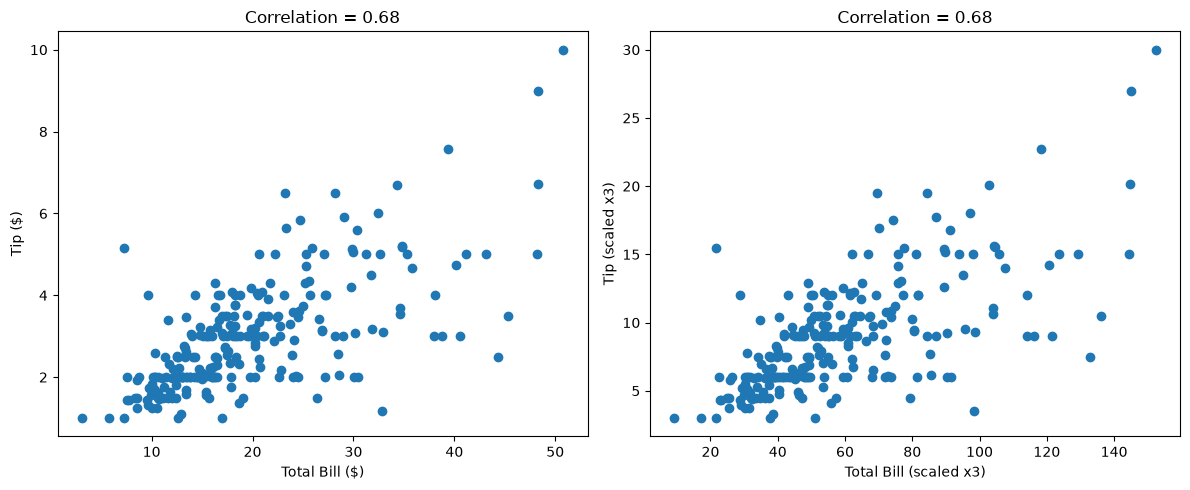

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['total_bill'], df['tip'])
axes[0].set_title(f"Correlation = {round(corr_original, 2)}")
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip ($)')

axes[1].scatter(df_scaled['total_bill_scaled'], df_scaled['tip_scaled'])
axes[1].set_title(f"Correlation = {round(corr_scaled, 2)}")
axes[1].set_xlabel('Total Bill (scaled x3)')
axes[1].set_ylabel('Tip (scaled x3)')

plt.tight_layout()
plt.show()

This is the whole point of correlation. Even though we scaled both variables by 3, the correlation stayed exactly **0.68** in both cases. Compare this to covariance, where the same scaling trick changed the number from 8.32 to 74.91.

The scatter plots confirm this visually too, the pattern of points is identical in both plots, just with bigger numbers on the axes. Correlation captures that the strength and direction of the relationship hasn't changed, while covariance was fooled by the change in scale.

A correlation of 0.68 tells us there's a **moderate to strong positive relationship** between total_bill and tip, bigger bills tend to come with bigger tips, but the relationship isn't perfectly tight, there's still a fair amount of scatter around the trend.

This is exactly why correlation is used far more often than covariance when comparing relationships, it gives a number that means the same thing regardless of what units the data happens to be in.